## Importing necessary libraries and loading the data

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

In [5]:
df = pd.read_excel("../data/customer_churn.xlsx",sheet_name=1,engine="openpyxl")

## Understanding the data

In [6]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [7]:
df.shape

(5630, 20)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [9]:
# check for missing values
df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [10]:
# duplicate values
df.duplicated().sum()

np.int64(0)

In [11]:
# if duplicate exist
df.drop_duplicates(inplace=True)

In [12]:
#unique values 
df.nunique()

CustomerID                     5630
Churn                             2
Tenure                           36
PreferredLoginDevice              3
CityTier                          3
WarehouseToHome                  34
PreferredPaymentMode              7
Gender                            2
HourSpendOnApp                    6
NumberOfDeviceRegistered          6
PreferedOrderCat                  6
SatisfactionScore                 5
MaritalStatus                     3
NumberOfAddress                  15
Complain                          2
OrderAmountHikeFromlastYear      16
CouponUsed                       17
OrderCount                       16
DaySinceLastOrder                22
CashbackAmount                 2586
dtype: int64

In [13]:
# Numerical and Categorial features 
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include='object').columns

print(num_cols)

print(cat_cols)

Index(['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
       'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
       'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
       'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')
Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')


## Univariate Analysis

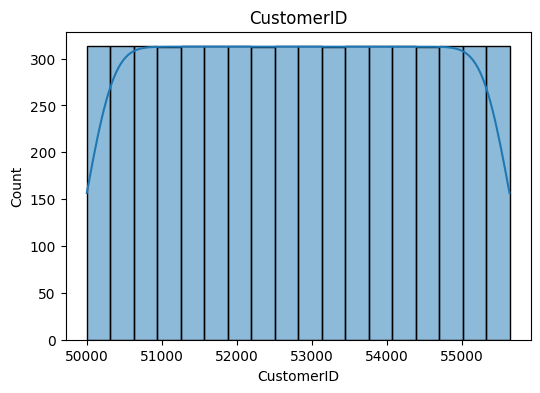

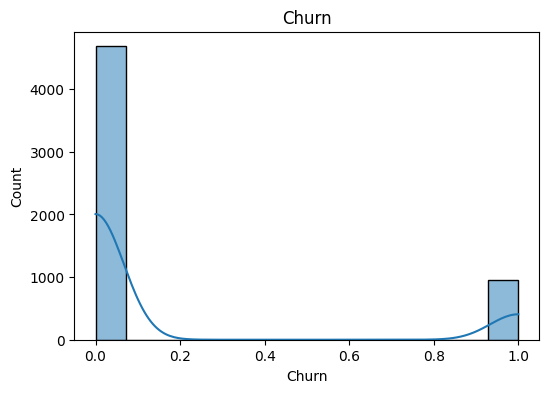

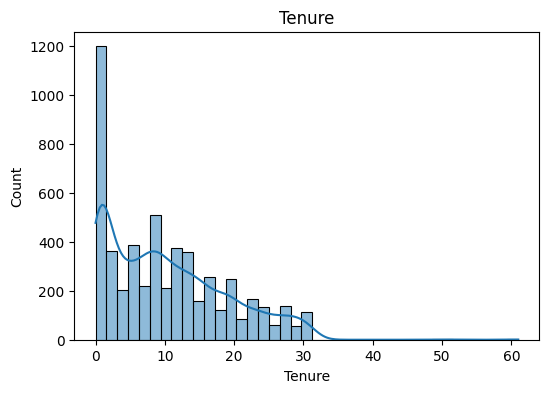

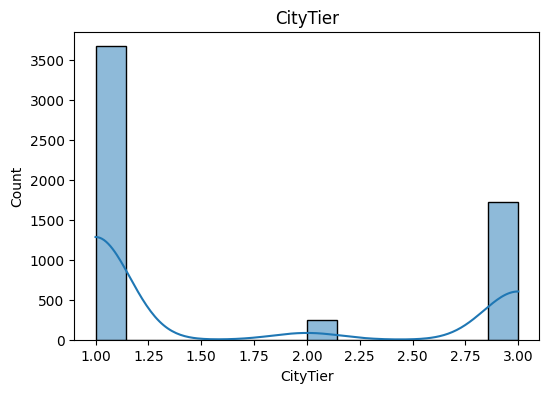

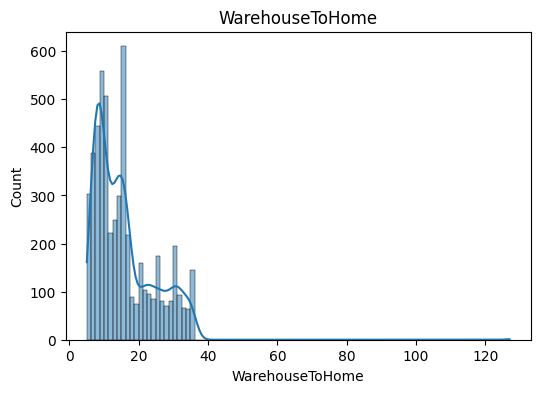

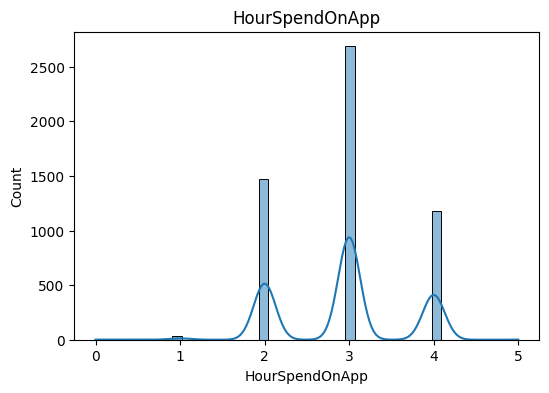

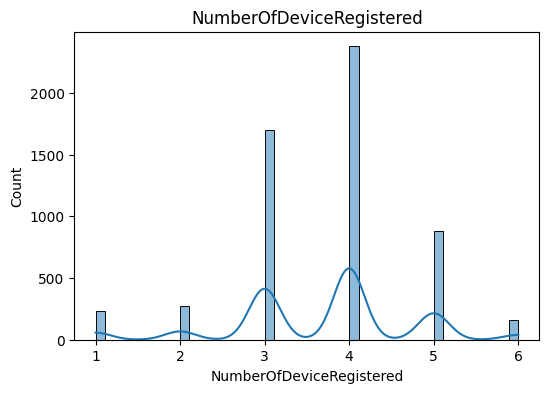

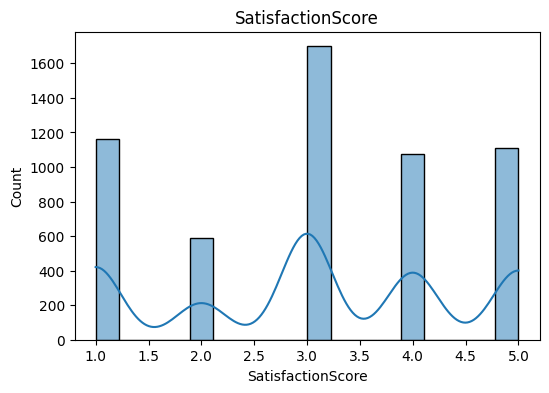

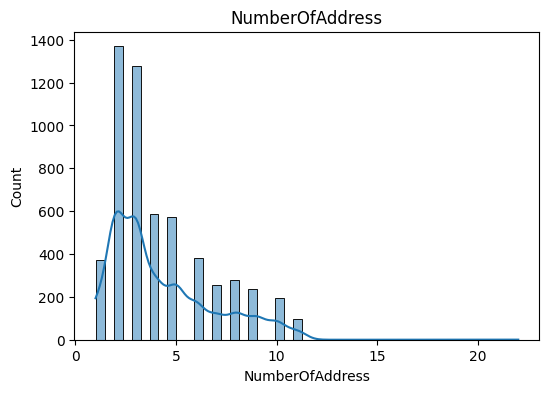

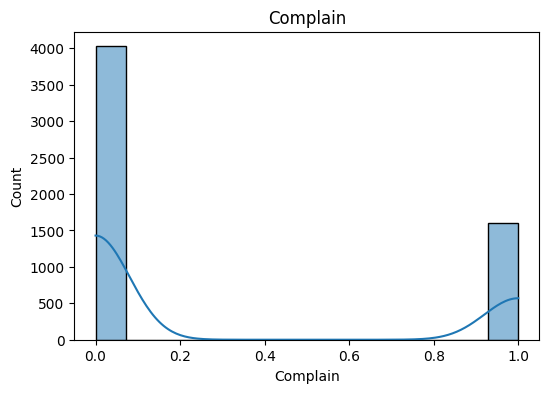

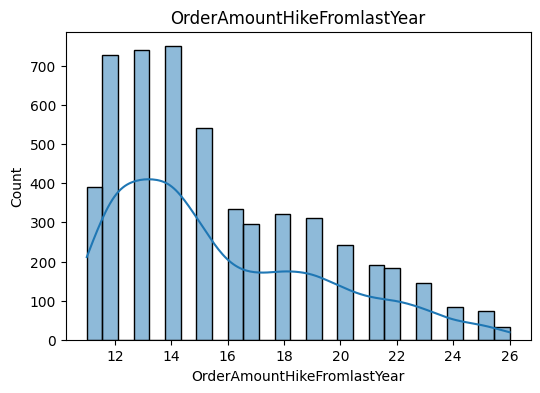

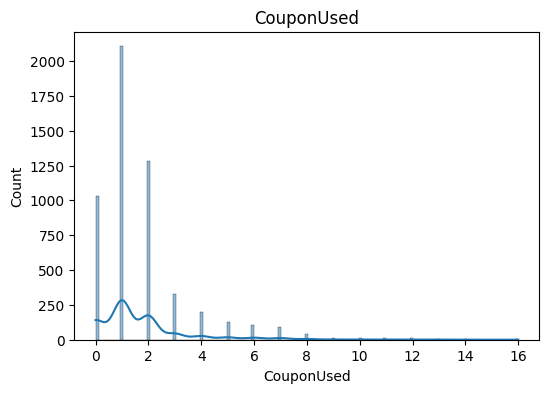

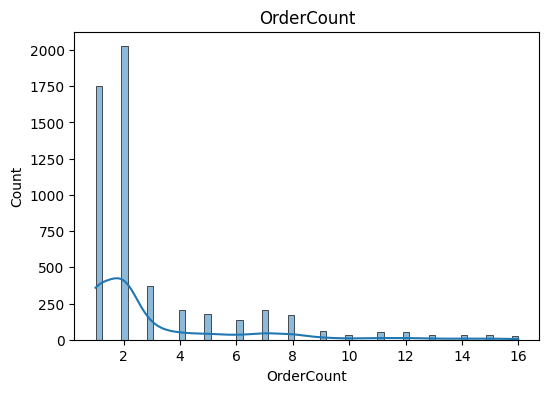

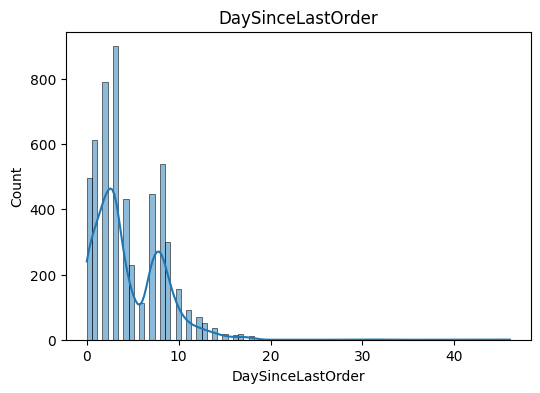

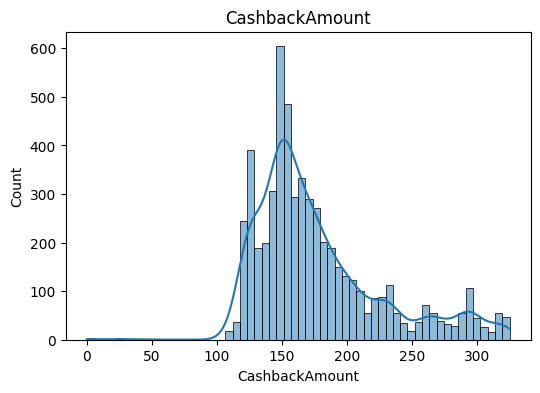

In [14]:

#Numerical features 
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

## Boxplots

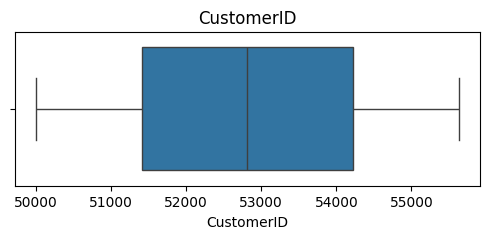

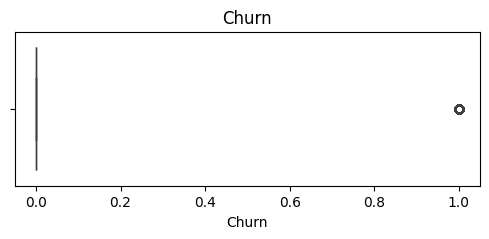

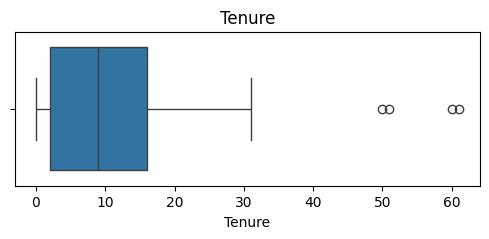

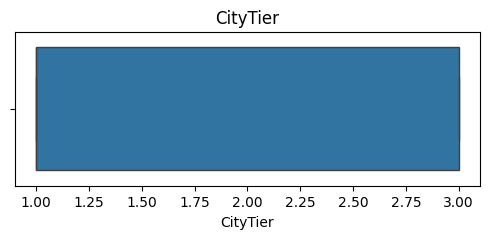

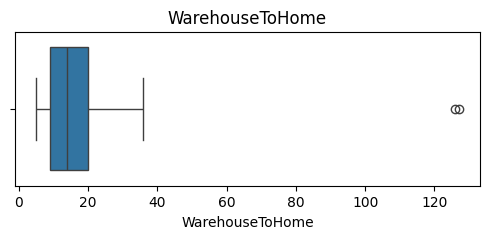

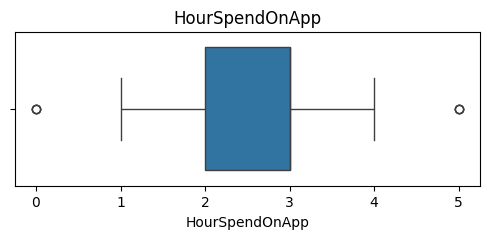

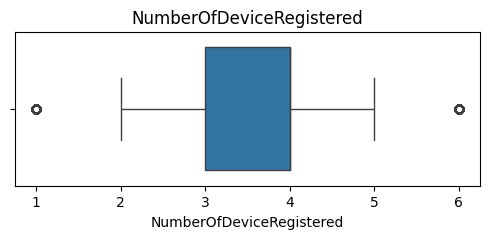

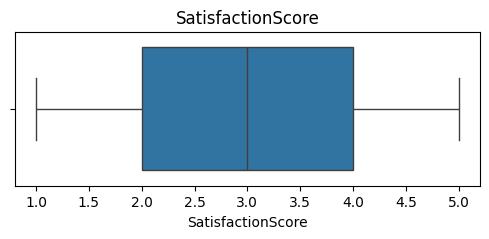

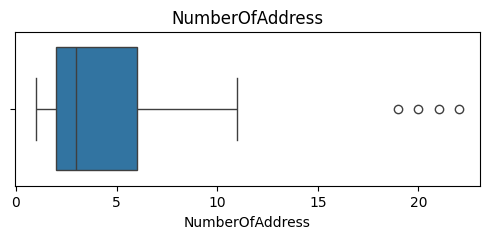

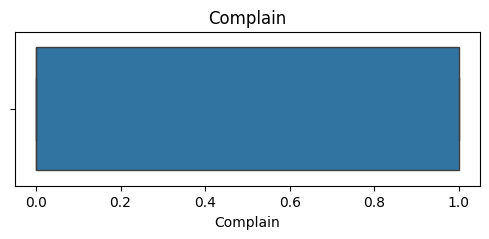

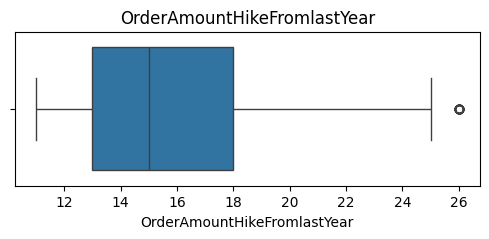

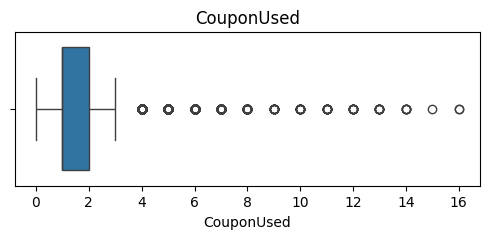

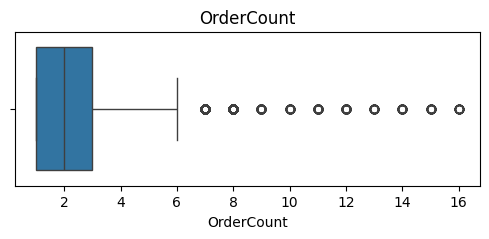

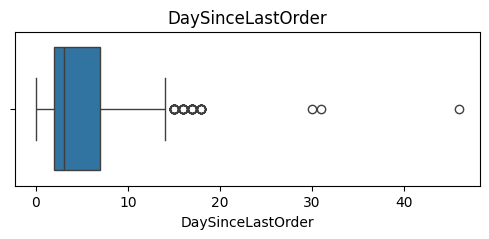

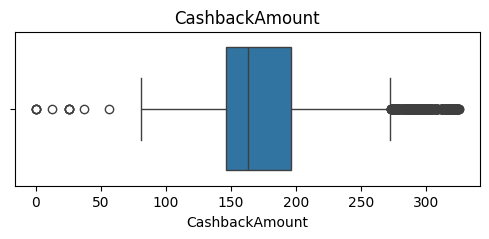

In [15]:
 
for col in num_cols:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

## Categorial Features 

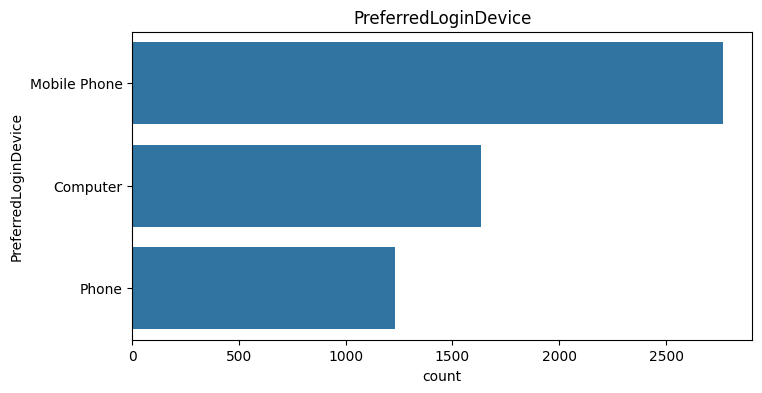

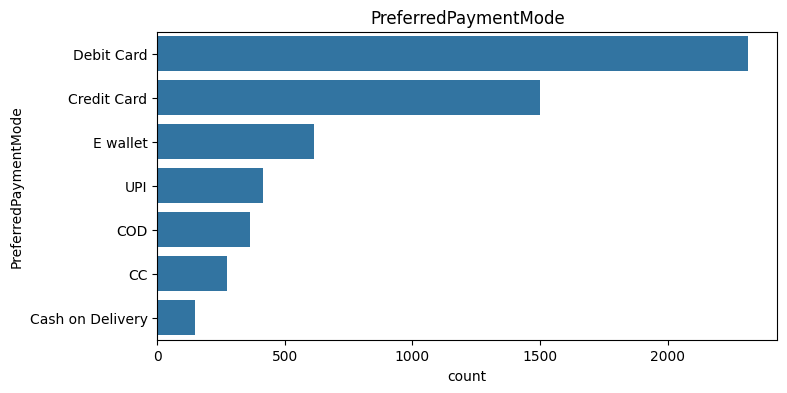

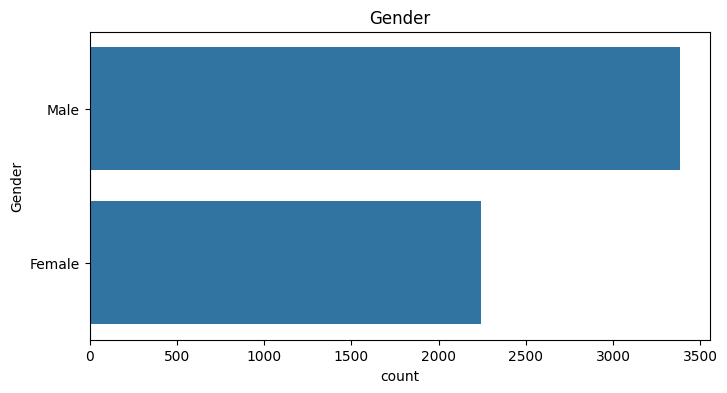

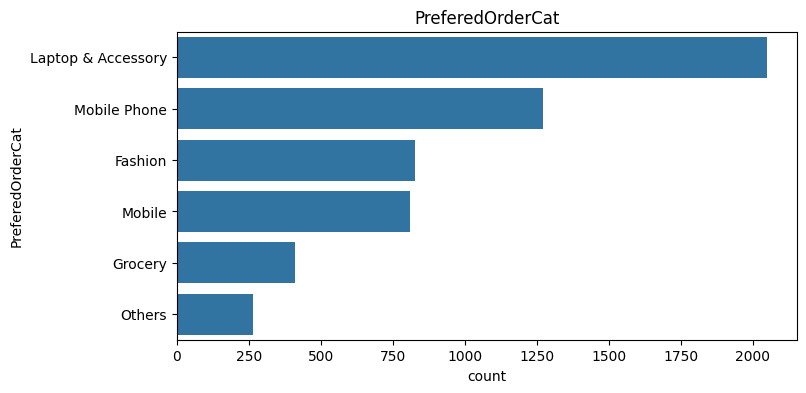

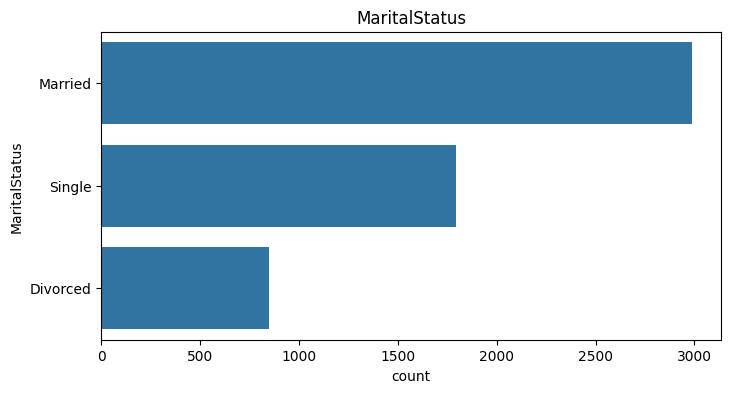

In [16]:
for col in cat_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(y=df[col], order=df[col].value_counts().index)

    plt.title(col)

    plt.show()

## Bivariate Analysis

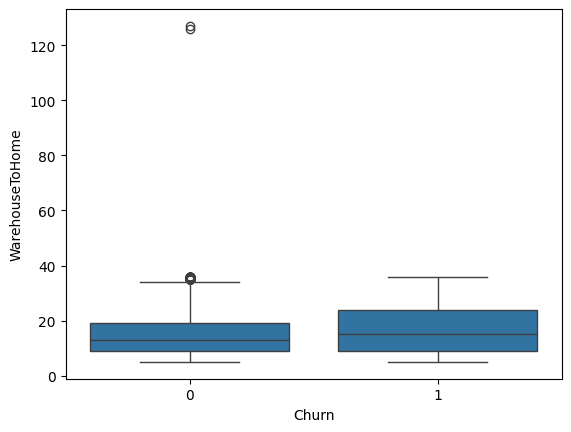

In [17]:
sns.boxplot(x='Churn',y='WarehouseToHome',data=df)

plt.show()

## Correlation Heatmap

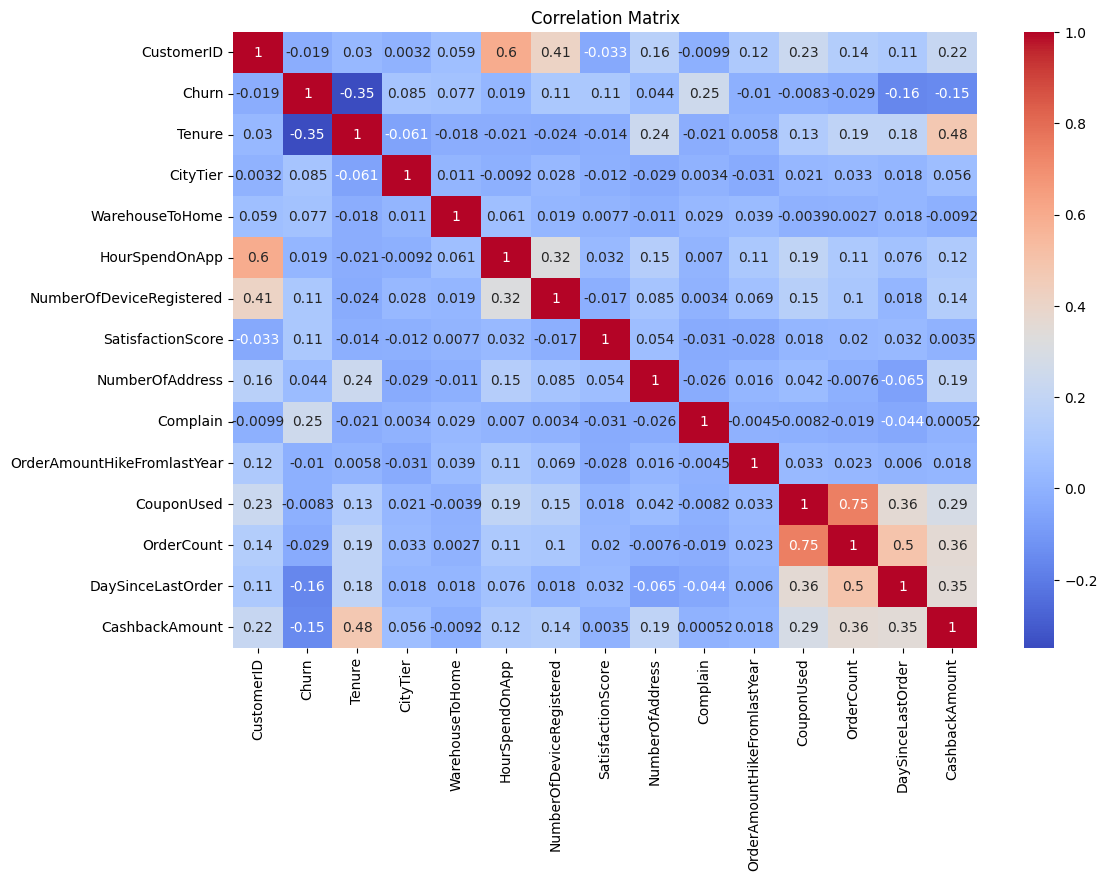

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),

            annot=True,

            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

## Outlier detection

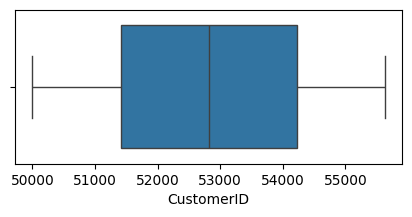

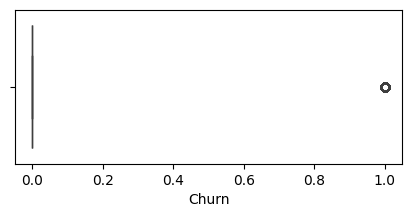

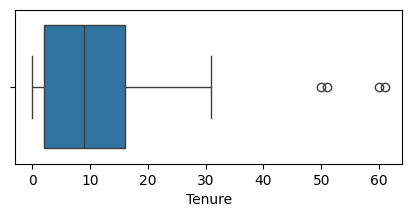

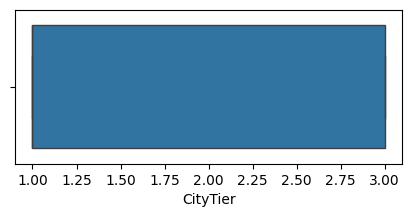

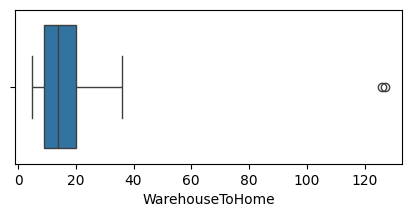

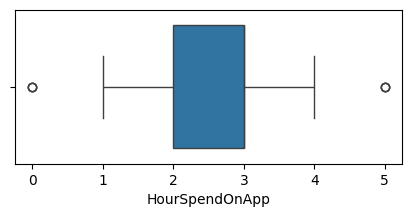

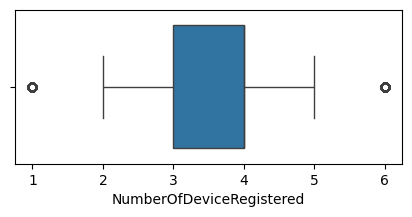

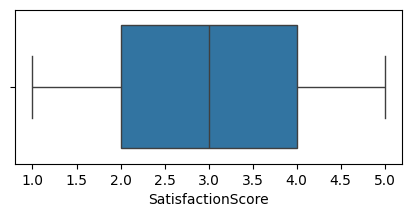

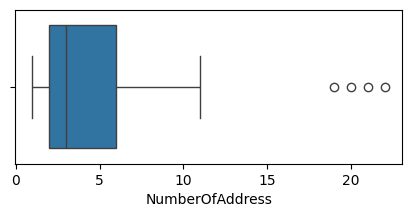

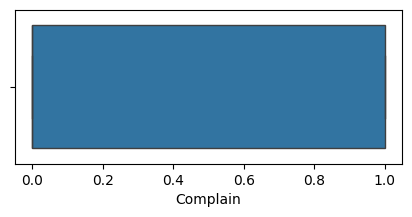

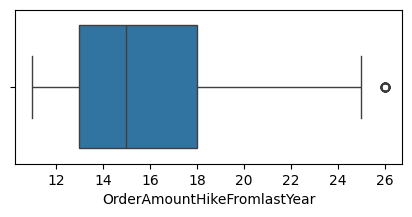

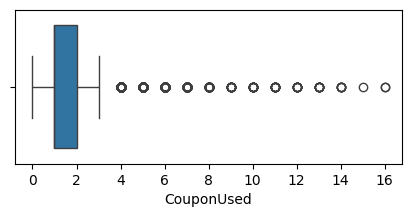

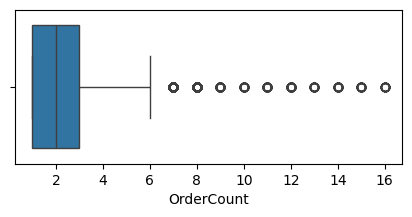

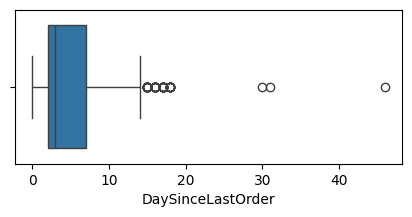

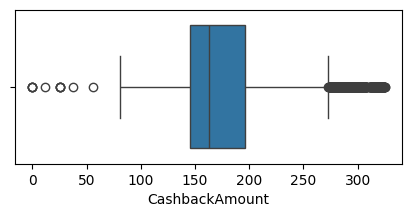

In [19]:
for col in num_cols:

    plt.figure(figsize=(5,2))

    sns.boxplot(x=df[col])

    plt.show()

# Business Insights 
After performing Exploratory Data Analysis (EDA), several important patterns were observed in the customer churn dataset.

1 Customers with shorter tenure were more likely to leave the company.

2 Customers who paid higher monthly charges showed a higher churn rate.

3 Customers using fiber optic internet had comparatively higher churn.

4 Customers with long-term contracts (One Year and Two Year) were less likely to churn.

5 Customers using electronic check as their payment method showed higher churn than other payment methods.

6 Senior citizens had a slightly higher churn percentage than younger customers.

## Automated EDA report

In [20]:
report = sv.analyze(df)

report.show_html("EDA_Report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report EDA_Report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


# Business Insights

The analysis provides several actionable insights for the business.

1. Focus on retaining new customers during their first few months.
2. Encourage customers to switch to yearly contracts by offering attractive discounts.
3. Improve customer service for fiber optic users to reduce dissatisfaction.
4. Offer personalized retention offers to customers with high monthly charges.
5. Promote automatic payment methods instead of electronic checks.
6. Build loyalty programs for customers who are at high risk of churning.

# Conclusion

The customer churn analysis provided meaningful insights into customer behavior and the factors contributing to customer attrition.

Major observations include:

* Customers with shorter tenure are more likely to churn.
* Higher monthly charges increase churn probability.
* Long-term contracts improve customer retention.
* Payment methods and internet services influence customer decisions.

Based on these findings, the organization should focus on customer engagement, personalized offers, and contract-based retention strategies to minimize churn and improve overall customer satisfaction.

This EDA serves as the foundation for predictive modeling, where machine learning algorithms can be trained to identify customers who are most likely to churn.

### Data preprocessing and model 

In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

Dropping customer id because don't help predict churn.
They are unique identifiers and keeping them may even reduce model performance.

In [22]:
df.drop(['CustomerID'], axis=1, inplace=True)

## Separate Features and Target

In [23]:
X = df.drop('Churn', axis=1)
y = df['Churn']

## Identify Numerical & Categorical Features

In [24]:
num_cols = X.select_dtypes(include = ["int64", "float64"]).columns

cat_cols = X.select_dtypes(include = ["object"]).columns

print("Numerical Features:", num_cols)
print("Categorical Features:", cat_cols)

Numerical Features: Index(['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
       'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')
Categorical Features: Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')


## Making a pipeline for numerical data

In [25]:
numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])

We use median because it is less affected by outliers than the mean.

## Making a pipeline for categorical data

In [26]:
categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))])

We have used most frequent categorical values to fill the missing values

## Combining Both Pipelines

In [27]:
preprocessor = ColumnTransformer([("num", numeric_pipeline, num_cols), ("cat", categorical_pipeline, cat_cols)])

## Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Creating a Model Evaluation Function

In [29]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    print("\nClassification Report:")

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    return accuracy, precision, recall, f1, roc_auc

We have made a function for easy model training and comparison.

## Logistic Regression

Accuracy: 0.8881
Precision: 0.7424
Recall: 0.5158
F1-Score: 0.6087
ROC-AUC: 0.8858

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       936
           1       0.74      0.52      0.61       190

    accuracy                           0.89      1126
   macro avg       0.82      0.74      0.77      1126
weighted avg       0.88      0.89      0.88      1126



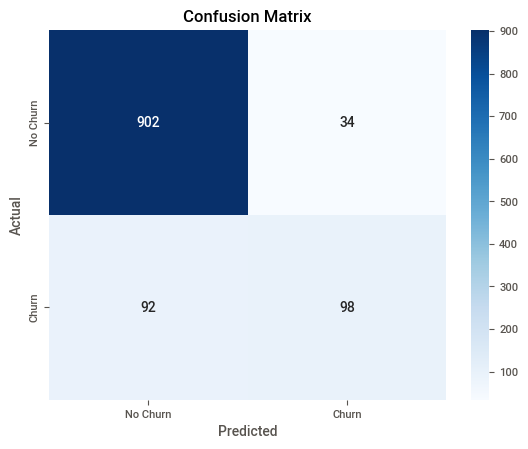

In [30]:
logistic_pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", LogisticRegression(random_state=42, max_iter=1000))])
logistic_pipeline.fit(X_train, y_train)
lr_metrics = evaluate_model(logistic_pipeline, X_test, y_test)

## Decision Tree

Accuracy: 0.9645
Precision: 0.8866
Recall: 0.9053
F1-Score: 0.8958
ROC-AUC: 0.9409

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       936
           1       0.89      0.91      0.90       190

    accuracy                           0.96      1126
   macro avg       0.93      0.94      0.94      1126
weighted avg       0.96      0.96      0.96      1126



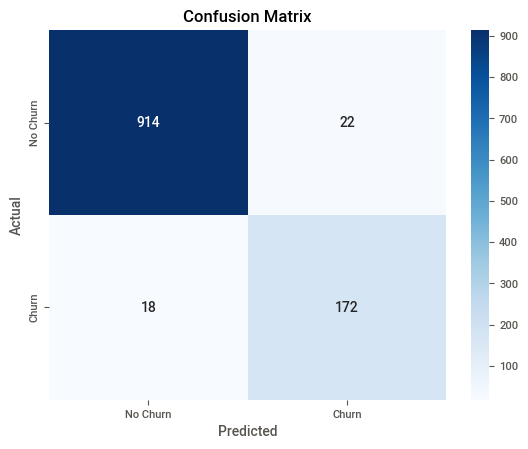

In [31]:
decision_tree_pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", DecisionTreeClassifier(random_state=42))])
decision_tree_pipeline.fit(X_train, y_train)

dt_metrics = evaluate_model(decision_tree_pipeline, X_test, y_test)

## Random Forest

Accuracy: 0.9760
Precision: 1.0000
Recall: 0.8579
F1-Score: 0.9235
ROC-AUC: 0.9989

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       936
           1       1.00      0.86      0.92       190

    accuracy                           0.98      1126
   macro avg       0.99      0.93      0.95      1126
weighted avg       0.98      0.98      0.98      1126



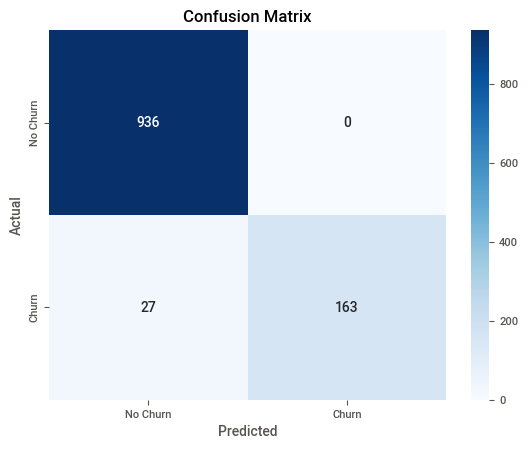

In [32]:
random_forest_pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", RandomForestClassifier(random_state=42))])
random_forest_pipeline.fit(X_train, y_train)

rf_metrics = evaluate_model(random_forest_pipeline, X_test, y_test)

## XGBoost

Accuracy: 0.9920
Precision: 0.9892
Recall: 0.9632
F1-Score: 0.9760
ROC-AUC: 0.9988

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       936
           1       0.99      0.96      0.98       190

    accuracy                           0.99      1126
   macro avg       0.99      0.98      0.99      1126
weighted avg       0.99      0.99      0.99      1126



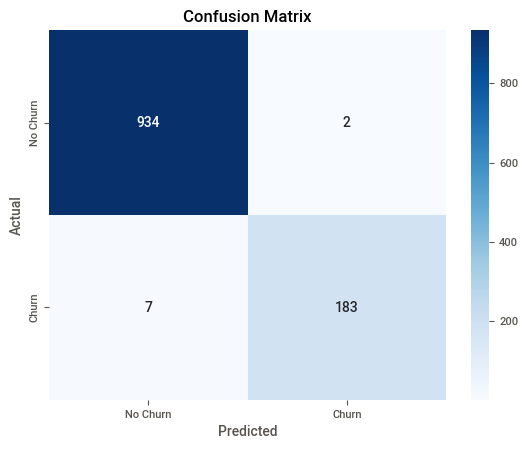

In [33]:
xgb_pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", XGBClassifier(random_state=42, eval_metric='logloss'))])
xgb_pipeline.fit(X_train, y_train)
xgb_metrics = evaluate_model(xgb_pipeline, X_test, y_test)

## Comparing Models

Accuracy alone can be misleading, especially if the classes are imbalanced.

ROC-AUC evaluates how well the model separates churners from non-churners across different thresholds, making it a stronger metric for comparing classification models would be helpful.

In [34]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        lr_metrics[0],
        dt_metrics[0],
        rf_metrics[0],
        xgb_metrics[0]
    ],

    "Precision":[
        lr_metrics[1],
        dt_metrics[1],
        rf_metrics[1],
        xgb_metrics[1]
    ],

    "Recall":[
        lr_metrics[2],
        dt_metrics[2],
        rf_metrics[2],
        xgb_metrics[2]
    ],

    "f1_score":[
        lr_metrics[3],
        dt_metrics[3],
        rf_metrics[3],
        xgb_metrics[3]
    ],

    "ROC-AUC":[
        lr_metrics[4],
        dt_metrics[4],
        rf_metrics[4],
        xgb_metrics[4]
    ]
})

results.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)


,Model,Accuracy,Precision,Recall,f1_score,ROC-AUC
0,Random Forest,0.976021,1.000000,0.857895,0.923513,0.998943
1,XGBoost,0.992007,0.989189,0.963158,0.976000,0.998791
2,Decision Tree,0.964476,0.886598,0.905263,0.895833,0.940879
3,Logistic Regression,0.888099,0.742424,0.515789,0.608696,0.885762


## Model Comparison

Four machine learning models were trained and evaluated using Accuracy, Precision, Recall and F1-score.
Top 2 models are - Random Forest and XGBoost.
ALthough random forest received slightly higher ROC-AUC, but the difference is negligible as compared to XGBoost.
Moreover, the recall value is evidently lower in Random Forest that means it misses churners. Missing a customer who is about to churn is usually more costly than wrongly flagging someone as at risk.

So the WINNER of this comparison is "XGBoost"

## Cross Validation

To ensure that the selected model generalizes well and is not dependent on a single train-test split,so we performed k-fold cross-validation on the best-performing model.

In [35]:
from sklearn.model_selection import cross_val_score

In [36]:
cv_scores = cross_val_score(
    xgb_pipeline, X_train, y_train, cv = 5, scoring = "accuracy"
)

print("Cross Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.96226415 0.95227525 0.95782464 0.95338513 0.96222222]
Mean Accuracy: 0.9575942779627574
Standard Deviation: 0.004225817221765836


## Cross Validation Results

To evaluate the generalization capability of the selected XGBoost model, 5 folds cross validation was performed.

RESULT :-
     . Mean Accuracy = 95.76%
     . Standard Derivation = 0.42%

The low SD indicates that the model is performing with consistency across different folds, suggesting good stability.

## Hyperparameter Tuning

After selecting XGBoost as the best-performing model, hyperparameter tuning was performed using RandomizedSearchCV to find the optimal combination of parameters and further improve model performance.

In [37]:
from sklearn.model_selection import RandomizedSearchCV

Creating a Parameter Grid

In [38]:
param_grid = {"classifier__n_estimators": [100,200,300], "classifier__max_depth": [3,5,7], "classifier__learning_rate": [0.01,0.1,0.2], "classifier__subsample": [0.8, 1.0]}

Using Random Search

In [39]:
random_search = RandomizedSearchCV(estimator=xgb_pipeline, param_distributions=param_grid, n_iter=10, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)

Training the Tuned Model

In [40]:
random_search.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__learning_rate': [0.01, 0.1, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__n_estimators': [100, 200, ...], 'classifier__subsample': [0.8, 1.0]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


Best Parameters

In [41]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.1}

Best Cross Validation Accuracy:
0.9595910716487852


Best Model

In [42]:
best_model = random_search.best_estimator_

Best Metrics

Accuracy: 0.9929
Precision: 0.9892
Recall: 0.9684
F1-Score: 0.9787
ROC-AUC: 0.9995

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       936
           1       0.99      0.97      0.98       190

    accuracy                           0.99      1126
   macro avg       0.99      0.98      0.99      1126
weighted avg       0.99      0.99      0.99      1126



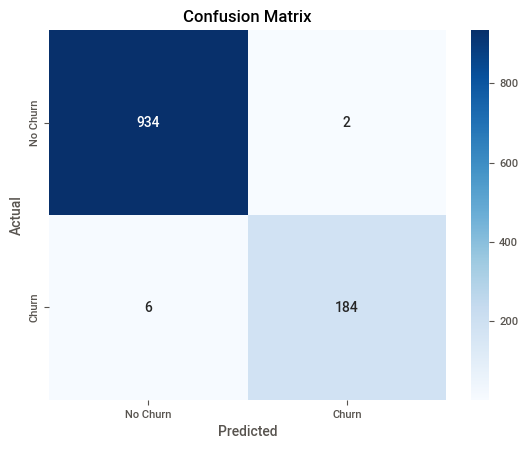

In [43]:
best_metrics = evaluate_model(
    best_model,
    X_test,
    y_test
)

## Hyperparameter Tuning Results

RandomizedSearchCV was used to optimize the XGBoost model.

The tuned model achieved better performance by selecting the optimal combination of hyperparameters.

The optimized model was selected as the final model for deployment.

### Extracting Feature Importance Scores

To better understand the trained XGBoost model, the feature importance scores are extracted from the model's booster object.

The **get_score()** function returns the importance score for each feature based on the selected importance type. In this project, the **gain** metric is used, which measures the average improvement in model performance whenever a feature is used to split the data.

These scores are later mapped to their corresponding feature names and visualized to identify the most influential factors affecting customer churn.

In [44]:
booster = best_model.named_steps["classifier"].get_booster()

scores = booster.get_score(importance_type="gain")

scores

{'f0': 7.577375411987305,
 'f1': 1.8984266519546509,
 'f2': 1.4207062721252441,
 'f3': 0.7820994257926941,
 'f4': 1.9568368196487427,
 'f5': 1.9368431568145752,
 'f6': 2.1641974449157715,
 'f7': 4.524475574493408,
 'f8': 1.2419910430908203,
 'f9': 1.371634602546692,
 'f10': 1.5361725091934204,
 'f11': 1.9321790933609009,
 'f12': 1.492034912109375,
 'f13': 2.089794874191284,
 'f14': 1.1844093799591064,
 'f15': 1.1381760835647583,
 'f16': 1.3215781450271606,
 'f17': 1.3969019651412964,
 'f18': 1.2624763250350952,
 'f19': 1.7559547424316406,
 'f20': 1.2918461561203003,
 'f21': 2.0108609199523926,
 'f22': 1.0635684728622437,
 'f23': 1.3227038383483887,
 'f25': 2.2324206829071045,
 'f26': 0.862952470779419,
 'f27': 2.5493946075439453,
 'f28': 1.2809354066848755,
 'f29': 1.8364784717559814,
 'f30': 1.40450918674469,
 'f31': 0.7852249145507812,
 'f32': 1.6059269905090332,
 'f33': 2.261960983276367}

In [45]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

In [46]:
importance = {}

for key, value in scores.items():
    index = int(key[1:])      # f0 -> 0
    importance[feature_names[index]] = value

### Creating the Feature Importance Table

The extracted feature importance scores are converted into a Pandas DataFrame for better readability and analysis.

The features are sorted in descending order based on their importance scores so that the most influential features appear first. Additionally, the prefixes (**num__** and **cat__**) added during preprocessing are removed to make the feature names more interpretable.

The resulting table provides a clear ranking of features based on their contribution to the XGBoost model.

In [47]:
importance_df = (
    pd.DataFrame(
        importance.items(),
        columns=["Feature", "Importance"]
    )
    .sort_values(by="Importance", ascending=False)
)

importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

importance_df

,Feature,Importance
0,Tenure,7.577375
7,Complain,4.524476
26,PreferedOrderCat_Laptop & Accessory,2.549395
32,MaritalStatus_Single,2.261961
24,PreferedOrderCat_Fashion,2.232421
6,NumberOfAddress,2.164197
13,PreferredLoginDevice_Computer,2.089795
21,PreferredPaymentMode_E wallet,2.010861
4,NumberOfDeviceRegistered,1.956837
5,SatisfactionScore,1.936843


# Feature Importance Analysis

After selecting the tuned XGBoost model as the final model, feature importance analysis was performed to understand which input features contributed the most to customer churn prediction.

XGBoost provides built-in feature importance scores based on the average gain achieved when a feature is used to split the data. Features with higher gain values have a greater influence on the model's predictions.

This analysis improves the interpretability of the model by highlighting the key factors associated with customer churn, allowing businesses to better understand the drivers behind customer behavior.

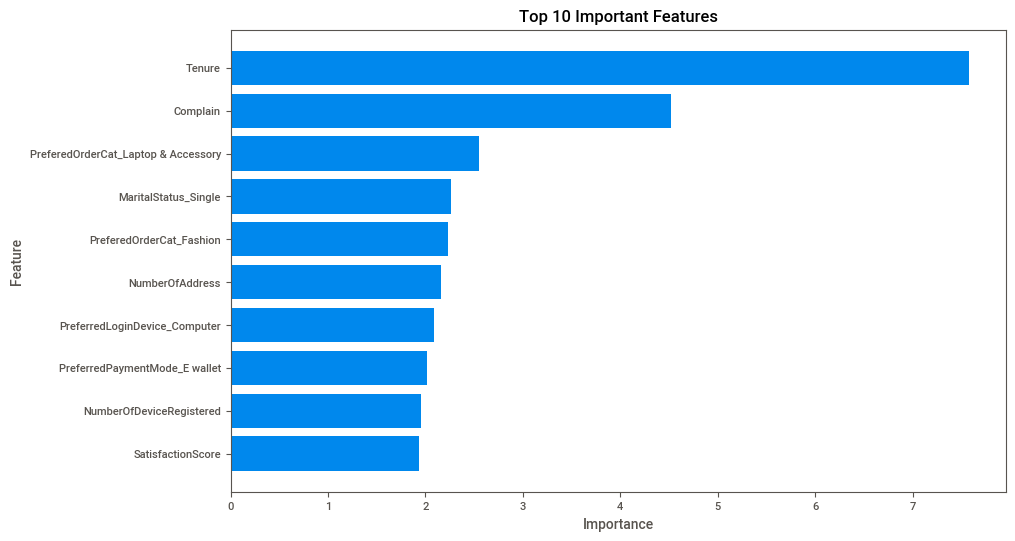

In [48]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"][:10],
    importance_df["Importance"][:10]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

## Interpretation

The graph shows the top 10 features that contributed the most to customer churn prediction. Features with higher importance values had a greater influence on the model's decisions.

The model identified features such as tenure, complaint history, and preferred order category among the strongest predictors of churn


### Saving the model 

In [49]:
import joblib

joblib.dump(best_model, "../Model/churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!
